In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression


In [34]:
from google.colab import files
uploaded = files.upload()

Saving Country-data.csv to Country-data (1).csv


In [35]:
df=pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [36]:
print(df.shape)
df.info()
df.describe().T

(167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [37]:
df.columns = [c.lower() for c in df.columns]
df.drop_duplicates(inplace=True)
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


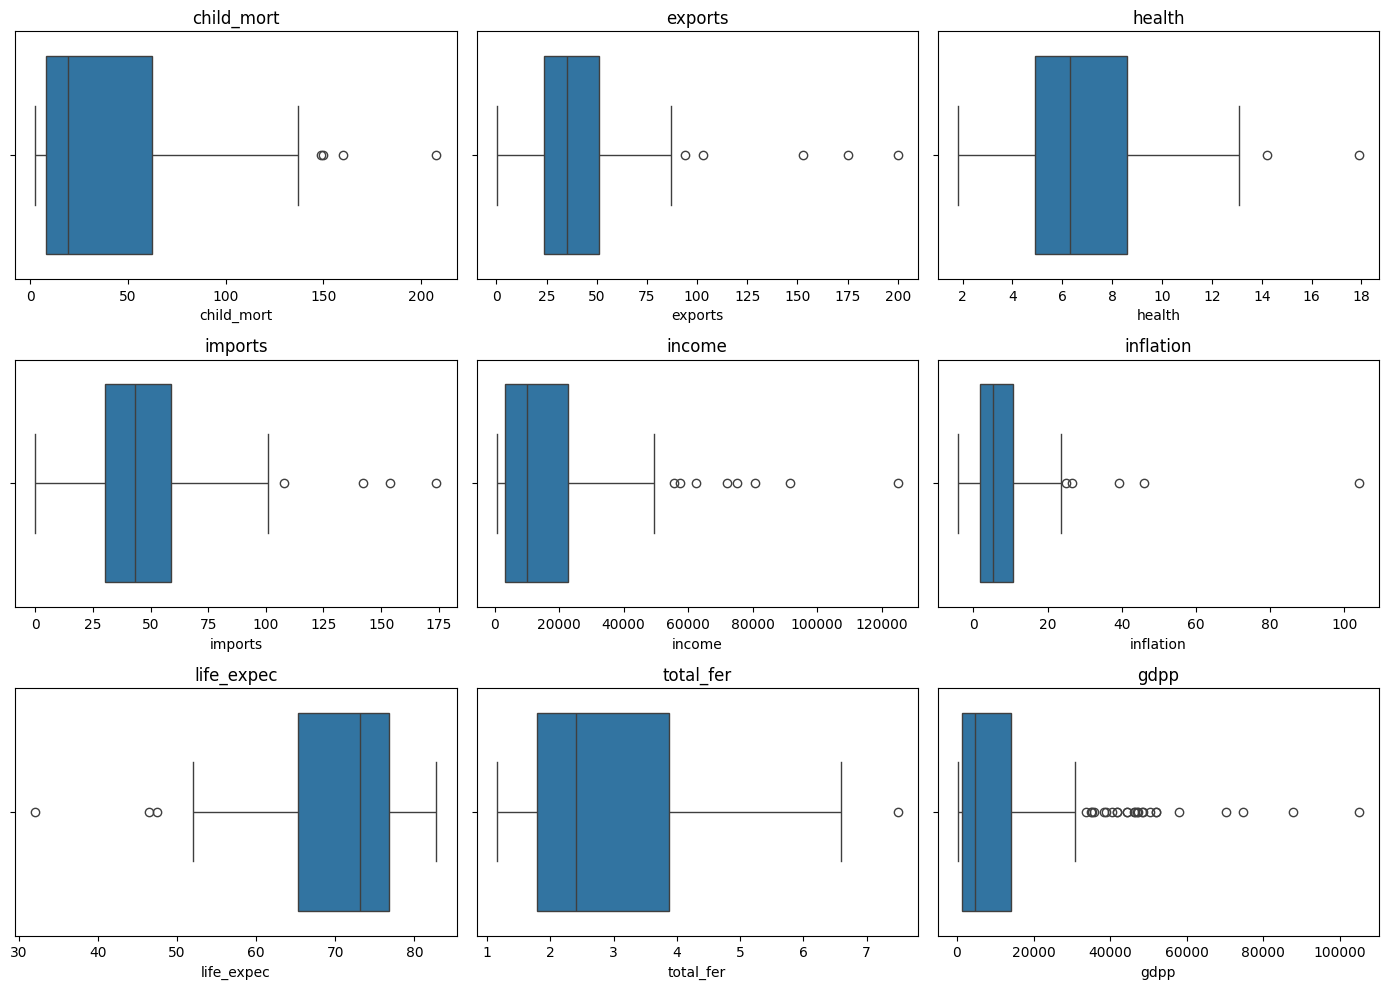

In [38]:
num_cols = [c for c in df.columns if c != "country"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [39]:
X = df[num_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

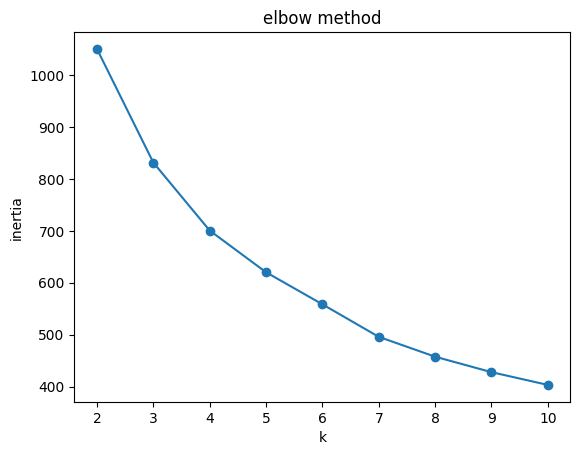

In [40]:
inertia = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("k")
plt.ylabel("inertia")
plt.title("elbow method")
plt.show()

In [41]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)
df["cluster"].value_counts()

,count
cluster,
2,84
1,47
0,36


In [42]:
db = DBSCAN(eps=1.5, min_samples=5)
df["dbscan_cluster"] = db.fit_predict(X_scaled)
df["dbscan_cluster"].value_counts()

,count
dbscan_cluster,
0,137
-1,30


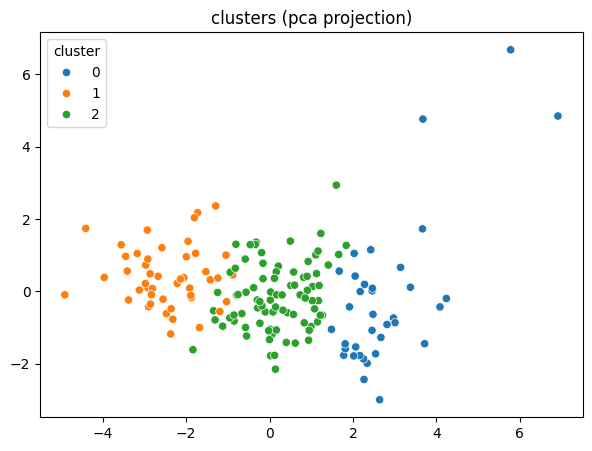

In [43]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["cluster"], palette="tab10")
plt.title("clusters (pca projection)")
plt.show()

In [44]:
df.groupby("cluster")[num_cols].mean().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


In [45]:
X_clf = df[num_cols]
y_clf = df["cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler2 = StandardScaler()
X_train_s = scaler2.fit_transform(X_train)
X_test_s = scaler2.transform(X_test)

In [46]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
rf_pred = rf.predict(X_test_s)

print("accuracy:", accuracy_score(y_test, rf_pred))
print("f1 macro:", f1_score(y_test, rf_pred, average="macro"))
print(classification_report(y_test, rf_pred))

accuracy: 1.0
f1 macro: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [47]:
xgb = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    random_state=42, eval_metric="mlogloss"
)
xgb.fit(X_train_s, y_train)
xgb_pred = xgb.predict(X_test_s)

print("accuracy:", accuracy_score(y_test, xgb_pred))
print("f1 macro:", f1_score(y_test, xgb_pred, average="macro"))
print(classification_report(y_test, xgb_pred))

accuracy: 0.9705882352941176
f1 macro: 0.9729323308270676
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



In [48]:
stack_clf = StackingClassifier(
    estimators=[("rf", rf), ("xgb", xgb)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1,
)
stack_clf.fit(X_train_s, y_train)
stack_pred = stack_clf.predict(X_test_s)

print("accuracy:", accuracy_score(y_test, stack_pred))
print("f1 macro:", f1_score(y_test, stack_pred, average="macro"))
print(classification_report(y_test, stack_pred))

accuracy: 0.9705882352941176
f1 macro: 0.9729323308270676
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



In [49]:
pd.DataFrame({
    "model": ["random forest", "xgboost", "stacking ensemble"],
    "accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, stack_pred),
    ],
    "f1_macro": [
        f1_score(y_test, rf_pred, average="macro"),
        f1_score(y_test, xgb_pred, average="macro"),
        f1_score(y_test, stack_pred, average="macro"),
    ],
}).round(4)

,model,accuracy,f1_macro
0,random forest,1.0000,1.0000
1,xgboost,0.9706,0.9729
2,stacking ensemble,0.9706,0.9729


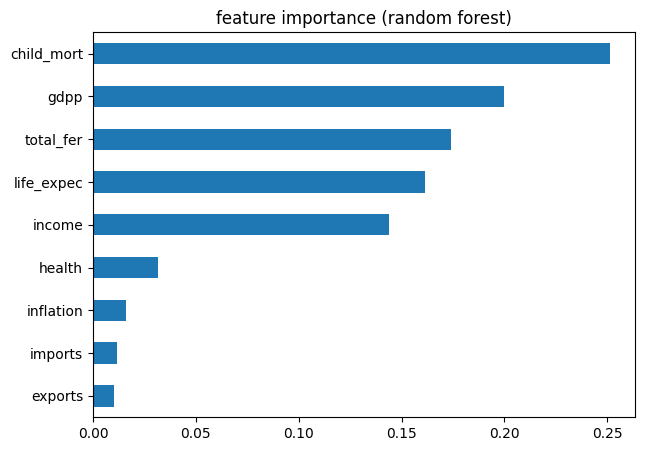

In [50]:
importances = pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False)
importances.plot(kind="barh", figsize=(7, 5))
plt.title("feature importance (random forest)")
plt.gca().invert_yaxis()
plt.show()